<a href="https://colab.research.google.com/github/aavarela/SPBD_Labs/blob/main/projeto2/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 2
This work was carried out by Afonso Varela (73544) and Gonçalo Dionísio (73638), with the help of Google Gemini 3 Pro (AI agent).

#Environment configuration

In [1]:
#@title Install & launch Kafka
%%bash
KAFKA_VERSION=3.7.2
KAFKA=kafka_2.12-$KAFKA_VERSION
wget -q -O /tmp/$KAFKA.tgz https://dlcdn.apache.org/kafka/$KAFKA_VERSION/$KAFKA.tgz
tar xfz /tmp/$KAFKA.tgz
wget -q -O $KAFKA/config/server1.properties - https://github.com/smduarte/spbd-2526/raw/refs/heads/main/docs/labs/projs/server1.properties

UUID=`$KAFKA/bin/kafka-storage.sh random-uuid`
$KAFKA/bin/kafka-storage.sh format -t $UUID -c $KAFKA/config/server1.properties
$KAFKA/bin/kafka-server-start.sh -daemon $KAFKA/config/server1.properties

Formatting /tmp/kraft-combined-logs with metadata.version 3.7-IV4.


In [2]:
#@title Install pyspark 3.5.7 for compatibility with spark-sql-kafka 3.5.7
!pip uninstall -y dataproc-spark-connect
!pip uninstall -y pyspark
!pip install pyspark==3.5.7

Found existing installation: dataproc-spark-connect 1.0.1
Uninstalling dataproc-spark-connect-1.0.1:
  Successfully uninstalled dataproc-spark-connect-1.0.1
Found existing installation: pyspark 4.0.1
Uninstalling pyspark-4.0.1:
  Successfully uninstalled pyspark-4.0.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.4/317.4 MB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.3 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.7-py2.py3-none-any.whl size=317907716 sha256=a639551388c835620ab1c3b9eed418ef16dca43b516a0a2709413f7a63926dde
  Stored in directory: /root/.cache/pip/wheels/f2/d3/02/10ad17f2eeb2cb9c800e320c8ca9ac87d0df8fe3adb8af7e95
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9


In [3]:
#@title Download 1% sample
!wget -q -O taxi_rides_1pc.csv.gz https://www.dropbox.com/scl/fi/v8ei5laqcalrx30z3lsty/taxi_rides_1pc.csv.gz?rlkey=q1lq7l56c4j97h9kymsdroau5&st=iurdwnwj&dl=0

In [4]:
#@title Start Kafka publisher
!pip --quiet install kafka-python dataclasses
!wget -q -O kafka-publisher.py https://raw.githubusercontent.com/smduarte/spbd-2526/refs/heads/main/docs/labs/projs/kafka-publisher.py

!nohup python kafka-publisher.py --topic taxis_json --speedup 120 --filename taxi_rides_1pc.csv.gz 2> /dev/null &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.3/326.3 kB 10.4 MB/s eta 0:00:00


# Data stream preparation

In [15]:
#@title Collect data
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

spark = SparkSession \
    .builder \
    .appName('Kafka Spark Structured Streaming Example') \
    .config('spark.jars.packages', 'org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.7') \
    .getOrCreate()

lines = spark \
  .readStream \
  .format('kafka') \
  .option('kafka.bootstrap.servers', 'localhost:9092') \
  .option('subscribe', 'taxis_json') \
  .option('startingOffsets', 'earliest') \
  .load() \
  .selectExpr('CAST(value AS STRING)')

# Define a StructType named taxi_ride_schema
taxi_ride_schema = StructType([
    StructField("medallion", StringType(), True),
    StructField("pickup_datetime", TimestampType(), True),
    StructField("dropoff_datetime", TimestampType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("pickup_latitude", DoubleType(), True),
    StructField("pickup_longitude", DoubleType(), True),
    StructField("dropoff_latitude", DoubleType(), True),
    StructField("dropoff_longitude", DoubleType(), True),
    StructField("pickup_grid_x", IntegerType(), True),
    StructField("pickup_grid_y", IntegerType(), True),
    StructField("dropoff_grid_x", IntegerType(), True),
    StructField("dropoff_grid_y", IntegerType(), True)
])

# Apply the from_json function to parse the JSON strings from lines
parsed_stream = lines.withColumn("parsed_value", from_json(col("value"), taxi_ride_schema))

# Select all fields from the parsed_value struct and project them directly
structured_stream = parsed_stream.select(col("parsed_value.*"))

MIN_LON = -74.916578
MAX_LAT = 41.47718278
LON_DELTA = 0.005986
LAT_DELTA = 0.004491556

processed_stream = structured_stream \
    .withColumn("pickup_grid_x", floor((MAX_LAT - col("pickup_latitude")) / LAT_DELTA)) \
    .withColumn("pickup_grid_y", floor((col("pickup_longitude") - MIN_LON) / LON_DELTA)) \
    .withColumn("dropoff_grid_x", floor((MAX_LAT - col("dropoff_latitude")) / LAT_DELTA)) \
    .withColumn("dropoff_grid_y", floor((col("dropoff_longitude") - MIN_LON) / LON_DELTA)) \
    .filter(
        (col("pickup_latitude").isNotNull()) & (col("pickup_longitude").isNotNull()) & \
        (col("dropoff_latitude").isNotNull()) & (col("dropoff_longitude").isNotNull()) & \
        (col("pickup_grid_x").between(0, 299)) & (col("pickup_grid_y").between(0, 299)) & \
        (col("dropoff_grid_x").between(0, 299)) & (col("dropoff_grid_y").between(0, 299)) & \
        (col("trip_distance") > 0)
    ) \
    .withColumn("trip_profit", col("fare_amount") + col("tip_amount"))

processed_stream_with_pickup_watermark = processed_stream.withWatermark("pickup_datetime", "10 minutes")
processed_stream_with_dropoff_watermark = processed_stream.withWatermark("dropoff_datetime", "10 minutes")

average_profit_per_area_stream = processed_stream_with_dropoff_watermark \
    .groupBy(
        window(col("dropoff_datetime"), "15 minutes"),
        col("pickup_grid_x"),
        col("pickup_grid_y")
    ) \
    .agg(avg("trip_profit").alias("average_trip_profit"))

dropoffs_for_empty = processed_stream_with_dropoff_watermark.select(
    col("medallion").alias("d_medallion"),
    col("dropoff_datetime").alias("d_time"),
    col("dropoff_grid_x").alias("d_grid_x"),
    col("dropoff_grid_y").alias("d_grid_y")
)

pickups_for_empty = processed_stream_with_pickup_watermark.select(
    col("medallion").alias("p_medallion"),
    col("pickup_datetime").alias("p_time"),
    col("pickup_grid_x").alias("p_grid_x"),
    col("pickup_grid_y").alias("p_grid_y")
)

empty_taxis_identification = dropoffs_for_empty.join(
    pickups_for_empty,
    expr("""
        d_medallion = p_medallion AND
        d_grid_x = p_grid_x AND
        d_grid_y = p_grid_y AND
        p_time BETWEEN d_time AND d_time + INTERVAL 30 MINUTES
    """),
    "leftOuter"
)

filtered_empty_taxis = empty_taxis_identification.filter(col("p_medallion").isNull())

empty_taxis_per_area_stream = filtered_empty_taxis \
    .groupBy(
        window(col("d_time"), "15 minutes"),
        col("d_grid_x"),
        col("d_grid_y")
    ) \
    .agg(count(col("d_medallion")).alias("empty_taxi_count"))

area_metrics_stream = average_profit_per_area_stream.join(
    empty_taxis_per_area_stream,
    (
        (average_profit_per_area_stream.window == empty_taxis_per_area_stream.window) &
        (average_profit_per_area_stream.pickup_grid_x == empty_taxis_per_area_stream.d_grid_x) &
        (average_profit_per_area_stream.pickup_grid_y == empty_taxis_per_area_stream.d_grid_y)
    ),
    "leftOuter"
).select(
    average_profit_per_area_stream.window,
    average_profit_per_area_stream.pickup_grid_x.alias("grid_x"),
    average_profit_per_area_stream.pickup_grid_y.alias("grid_y"),
    col("average_trip_profit"),
    coalesce(col("empty_taxi_count"),lit(0)).alias("empty_taxi_count")
)

area_profitability = area_metrics_stream.withColumn(
    "profitability",
    when(col("empty_taxi_count") == 0, 0.0)
    .otherwise(col("average_trip_profit") / col("empty_taxi_count"))
).select(
    col("window"),
    col("grid_x"),
    col("grid_y"),
    col("profitability")
)

# Collect area profitability data

In [16]:
import time
import pandas as pd

# Stop any previous active queries
for q in spark.streams.active:
    q.stop()
print("All currently active streaming queries stopped.")

# Start a streaming query to collect the data
data_query = area_profitability \
    .writeStream \
    .outputMode("append") \
    .format("memory") \
    .queryName("collected_data") \
    .start()

print("Streaming query started.")

print("Waiting to allow data to be collected.")
time.sleep(900)

# Stop the streaming query
data_query.stop()

print("Streaming query stopped. Data collection complete.")

# Retrieve the collected data from the memory sink into a Pandas DataFrame
area_profitability_df = spark.sql("SELECT * FROM collected_data").toPandas()

# Display the collected data
print("Displaying the first 5 rows of the collected data:")
display(area_profitability_df.head())

print(f"Total rows in area_profitability data: {len(area_profitability_df)}")

All currently active streaming queries stopped.
Streaming query started.
Waiting to allow data to be collected.
Streaming query stopped. Data collection complete.
Displaying the first 5 rows of the collected data:


,window,grid_x,grid_y,profitability
0,"(2025-12-19 10:00:00, 2025-12-19 10:15:00)",169,160,5.375000
1,"(2025-12-19 10:00:00, 2025-12-19 10:15:00)",174,155,4.375000
2,"(2025-12-19 10:00:00, 2025-12-19 10:15:00)",163,169,0.000000
3,"(2025-12-19 10:00:00, 2025-12-19 10:15:00)",165,156,2.676786
4,"(2025-12-19 10:00:00, 2025-12-19 10:15:00)",149,160,0.000000


Total rows in area_profitability data: 589


# 1. Analysis of the area profitability data

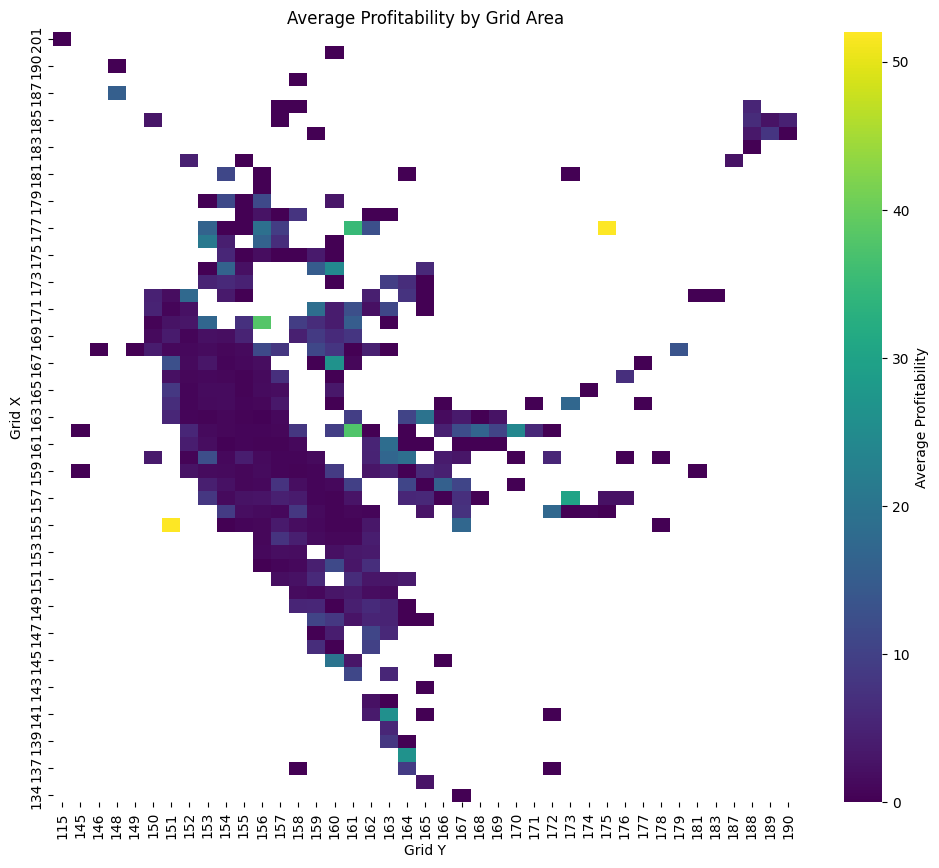

In [17]:
#@title Show a heat map of the area profitability data
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate profitability by grid coordinates
aggregated_profitability = area_profitability_df.groupby(['grid_x', 'grid_y'])['profitability'].mean().reset_index()

# Pivot the data for heatmap
heatmap_data = aggregated_profitability.pivot_table(index='grid_x', columns='grid_y', values='profitability')

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='viridis', annot=False, fmt=".1f", cbar_kws={'label': 'Average Profitability'})
plt.title('Average Profitability by Grid Area')
plt.xlabel('Grid Y')
plt.ylabel('Grid X')
plt.gca().invert_yaxis() # Invert y-axis to have (0,0) at top-left, matching typical grid representation
plt.show()

In [18]:
#@title Show some key summary statistics of the area profitability data
print("Key Summary Statistics for Average Profitability:")
display(aggregated_profitability['profitability'].describe())

Key Summary Statistics for Average Profitability:


,profitability
count,380.000000
mean,4.671271
std,7.030885
min,0.000000
25%,0.497471
50%,2.069716
75%,6.012500
max,52.000000


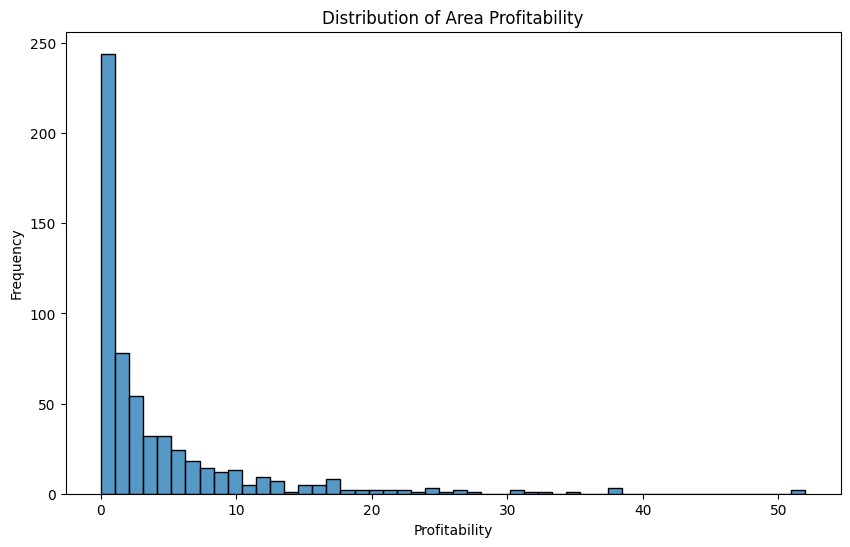

In [19]:
#@title Show histogram of the area profitability data
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(area_profitability_df['profitability'], bins=50)
plt.title('Distribution of Area Profitability')
plt.xlabel('Profitability')
plt.ylabel('Frequency')
plt.show()


## Observations:
*   **Distribution Shape**: The histogram shows a skewed distribution, heavily concentrated towards lower profitability values, including a significant number of areas with zero profitability.
*   **Concentration at Zero**: A large peak at profitability = 0 indicates many grid areas likely had no trips or no successful trips during the observed time windows, or perhaps the formula resulted in zero for other reasons.
*   **Range**: While many areas have low profitability, there's a long tail extending to higher profitability values, suggesting a few highly profitable areas.
*   **Interpretation**: This implies that profitability is not uniformly distributed across the grid. There are specific areas that are very profitable, while a substantial number of areas yield little to no profit.

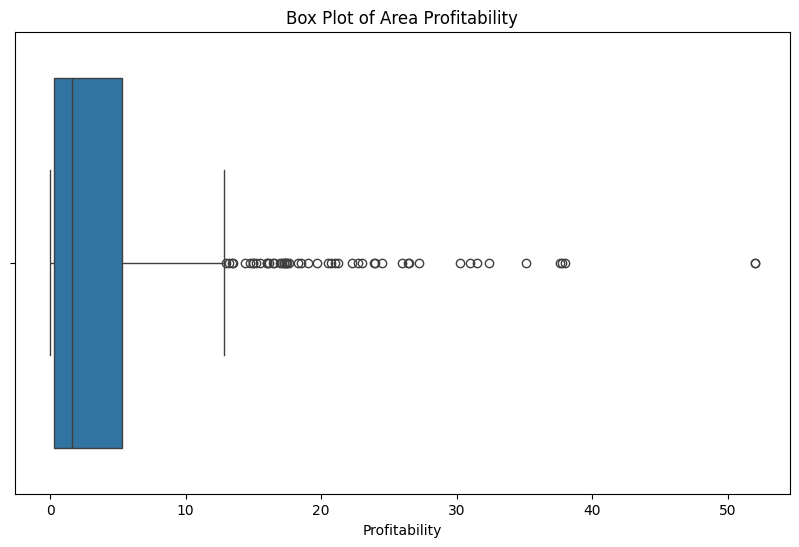

In [20]:
#@title Show the box plot of the area profitability data
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=area_profitability_df['profitability'])
plt.title('Box Plot of Area Profitability')
plt.xlabel('Profitability')
plt.show()

## Observations:
*   **Median and Quartiles**: The box plot clearly indicates that the median profitability is very low, likely at or near zero. The first quartile (Q1) and third quartile (Q3) are also low, reinforcing the observation from the histogram that most areas have low profitability.
*   **Outliers**: The box plot shows a considerable number of individual data points extending far above the upper whisker. These represent significant outliers – areas with exceptionally high profitability compared to the majority.
*   **Spread**: The interquartile range (IQR) is relatively small, indicating that the bulk of the data (the middle 50%) is tightly clustered at lower profitability values.
*   **Interpretation**: The box plot visually confirms the presence of highly profitable hotspots (outliers) that stand out from the vast majority of areas, which exhibit very low or zero profitability. This suggests that identifying and focusing on these high-profitability areas could be crucial for optimizing taxi operations.

## Analysis key findings
*   The profitability distribution is heavily skewed, with a significant concentration of areas showing low or zero profitability.
*   A prominent peak at profitability = 0 suggests many grid areas had no trips or no successful trips, or yield no profit.
*   While most areas have low profitability, there is a long tail extending to higher values, indicating the presence of a few exceptionally profitable areas.
*   The median profitability is very low, close to zero, and the first and third quartiles are also low, reinforcing that the majority of areas are not highly profitable.
*   The box plot clearly identifies a considerable number of outliers, representing areas with exceptionally high profitability, significantly above the median and the bulk of the data.
*   The interquartile range (IQR) is relatively small, showing that the central 50% of areas are clustered at very low profitability levels.

# 2. How does the trip profitability depend on the trip distance?

#3. How does the profitability depend on the trip time of day

# Addendum